# RQ3: Reskilling intensity
Felix Zaussinger | 15.06.2021, adapted to new ESCO version on 05.09.2022

**Core Analysis Goal(s)**
1. How close are occupations likely less demanded in a green transition to those being more demanded? (~ reskilling intensity)
2. Further disaggregate the analysis to the ISCO-08 1-digit level groups?

**Key Insight(s)**
1. Ranking of average similarities is surprising. Only looking at occupation similarity, brown occupations are on average closer to green occupations than neutral occupations.
    - Neutral & Green
    - Brown & Green
    - Brown & Neutral
2. Cross-pair differences are statistically significant at p < 0.001
3. Between-pair differences not significant at p < 0.001 are neutral-green and green-brown
4. Results are not robust to changing the similarity matrix (upeksha vs kanders).
using Upeksha's matrix, green-brown is closest, followed by green-neutral and neutral-brown

In [1]:
import copy
import os
import sys
import logging
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils

# import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.5)

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.2f}".format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

# pd.set_option("display.precision", 4)

ESCO data set components

In [2]:
from src.data.framework import Esco

esco = Esco()
occ = esco.occupations
skill_groups = esco.skills_groups
skills = esco.skills
occ_skills_mapping = esco.occupations_to_skills

Read GBN classification

In [3]:
df_metadata_raw = esco.read_gbn_classification()
df_metadata_raw

,conceptUri,preferredLabel,classification_sl,isco_level_4,isco_level_3,isco_level_2,isco_level_1,classification_slt
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,neutral,2654,265,26,2,neutral
1,http://data.europa.eu/esco/occupation/1a7fb683...,video and motion picture director,neutral,2654,265,26,2,neutral
2,http://data.europa.eu/esco/occupation/2f372afe...,performance lighting director,neutral,2654,265,26,2,neutral
3,http://data.europa.eu/esco/occupation/30b25ee4...,animation director,neutral,2654,265,26,2,neutral
4,http://data.europa.eu/esco/occupation/3b6bea7d...,video and motion picture producer,neutral,2654,265,26,2,neutral
...,...,...,...,...,...,...,...,...
3003,http://data.europa.eu/esco/occupation/b059d331...,hawker,neutral,9520,952,95,9,neutral
3004,http://data.europa.eu/esco/occupation/96a0d8d3...,quick service restaurant crew member,neutral,9411,941,94,9,neutral
3005,http://data.europa.eu/esco/occupation/a02a1117...,pizzaiolo,neutral,9411,941,94,9,neutral
3006,http://data.europa.eu/esco/occupation/e1cf6897...,kitchen assistant,neutral,9412,941,94,9,neutral


##### Descriptive Statistics about GBN Classifications

In [4]:
df_metadata_raw.groupby("classification_slt").count()

,conceptUri,preferredLabel,classification_sl,isco_level_4,isco_level_3,isco_level_2,isco_level_1
classification_slt,,,,,,,
brown,63,63,63,63,63,63,63
green,91,91,91,91,91,91,91
neutral,2854,2854,2854,2854,2854,2854,2854


In [5]:
(df_metadata_raw.groupby("classification_slt").count() / 3008) * 100

,conceptUri,preferredLabel,classification_sl,isco_level_4,isco_level_3,isco_level_2,isco_level_1
classification_slt,,,,,,,
brown,2.09,2.09,2.09,2.09,2.09,2.09,2.09
green,3.03,3.03,3.03,3.03,3.03,3.03,3.03
neutral,94.88,94.88,94.88,94.88,94.88,94.88,94.88


In [6]:
df_metadata_raw.groupby("classification_sl").count()

,conceptUri,preferredLabel,isco_level_4,isco_level_3,isco_level_2,isco_level_1,classification_slt
classification_sl,,,,,,,
brown,207,207,207,207,207,207,207
green,91,91,91,91,91,91,91
neutral,2710,2710,2710,2710,2710,2710,2710


In [7]:
(df_metadata_raw.groupby("classification_sl").count() / 3008) * 100

,conceptUri,preferredLabel,isco_level_4,isco_level_3,isco_level_2,isco_level_1,classification_slt
classification_sl,,,,,,,
brown,6.88,6.88,6.88,6.88,6.88,6.88,6.88
green,3.03,3.03,3.03,3.03,3.03,3.03,3.03
neutral,90.09,90.09,90.09,90.09,90.09,90.09,90.09


#### Remove military occupations from df_metadata
21 occupations in total, all coded as neutral

ISCO codes (n=21)
- 110: n=12
- 210: n=4
- 310: n=5

In [8]:
cond = df_metadata_raw.isco_level_4.isin(["0110", "0210", "0310"])
cond.name = "military"
df_cond = cond.reset_index()

# for re-indexing the sim matrices
non_military_indices = df_metadata_raw[~cond].index.values

df_metadata = df_metadata_raw.loc[~cond]
df_metadata = df_metadata.reset_index(drop=True)

In [9]:
non_military_indices

array([   0,    1,    2, ..., 3005, 3006, 3007], dtype=int64)

#### Calculate occupation similarity matrix
- Weighted vs unweighted cooc matrix
- Nesta matrix

In [10]:
# read bipartite adjecency matrix for occupations and skills
import scipy

version = "weighted"
osm = esco.read_occ_skills_matrix(return_version=version)
osm_sparse = scipy.sparse.csr_matrix(osm.values)

# Co-occurrence matrix
sim_matrix_sparse = osm_sparse.dot(osm_sparse.T)
sim_matrix = sim_matrix_sparse.toarray()
np.fill_diagonal(sim_matrix, 0)

##### Descriptive Statistics of Weighted Skill Overlap Matrix (Excluding self-transitions)

In [11]:
s_sims = pd.Series(sim_matrix.flatten())
s_sims.describe()

count   9,048,064.00
mean            0.46
std             2.06
min             0.00
25%             0.00
50%             0.00
75%             0.25
max            82.00
dtype: float64

In [12]:
from scipy import stats
stats.iqr(s_sims)

0.25

Plot distribution

In [13]:
sim_matrix_1d = sim_matrix.flatten()

In [14]:
qs = [0.99]
quantiles = np.quantile(sim_matrix_1d, qs)

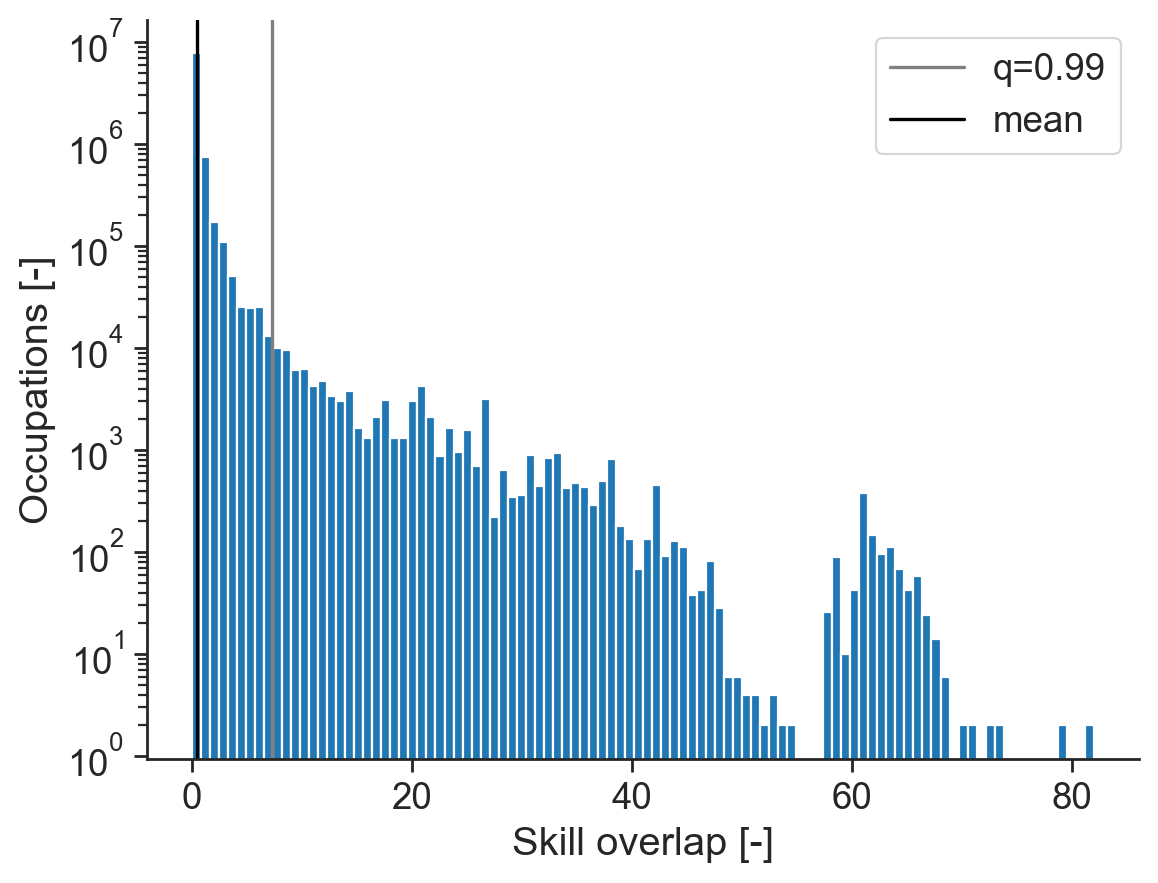

In [15]:
plt.hist(sim_matrix_1d, bins=100)
plt.yscale("log")

for val, q in zip(quantiles, qs):
    plt.axvline(val, color="grey", label="q={}".format(q))
plt.axvline(sim_matrix_1d.mean(), color="k", label="mean")

plt.legend()
sns.despine()
plt.xlabel("Skill overlap [-]")
plt.ylabel("Occupations [-]")

# save
out_path = os.path.join(
    useful_paths.figure_dir,
    "occupation_skill_space",
    "occ_sim_matrix_{}_skills_overlap.png".format(version),
)

plt.savefig(
    out_path,
    bbox_inches="tight",
    dpi=300,
)

In [16]:
# reindex by isco level
reindex_by_isco4 = esco.occupations.sort_values("iscoGroup").index.values
x, y = np.meshgrid(reindex_by_isco4, reindex_by_isco4)

Sort classification categories by isco 4d

,conceptUri,preferredLabel,isco_level_4,isco_level_3,isco_level_2,isco_level_1,classification_slt
classification_sl,,,,,,,
brown,207,207,207,207,207,207,207
green,91,91,91,91,91,91,91
neutral,2710,2710,2710,2710,2710,2710,2710


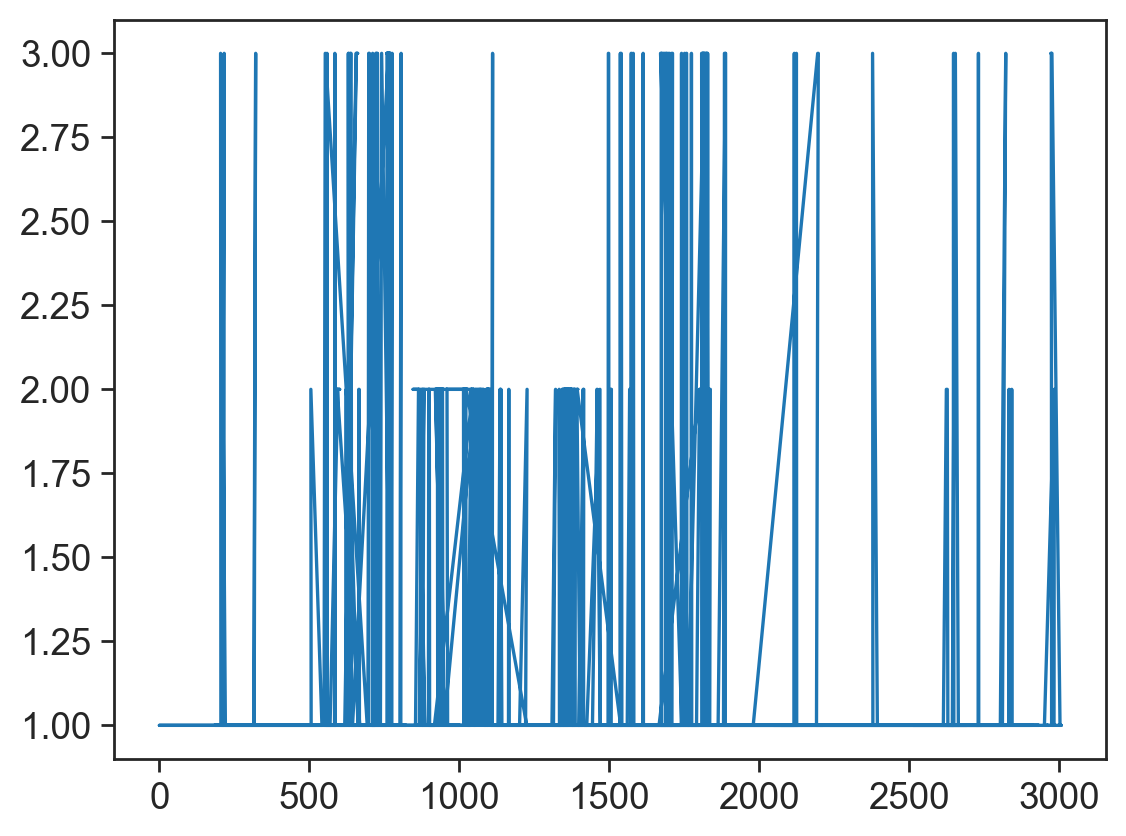

In [17]:
reindex_sl_by_isco4d = df_metadata_raw.sort_values("isco_level_4").loc[
    :, "classification_sl"
]
x, y = np.meshgrid(reindex_sl_by_isco4d, reindex_sl_by_isco4d)

rdict = {"green": 3, "brown": 2, "neutral": 1}
reindex_sl_by_isco4d.replace(rdict).plot()
df_metadata_raw.groupby("classification_sl").count()

x: all cols have the same class
y: all rows have the same class

#### Transition matrix for GBN categories: version 1

In [18]:
# import copy
#
# transition_matrix = y + "2" + x
#
# transition_matrix_mapping = {
#     "brown2green": 0,
#     "brown2neutral": 1,
#     "brown2brown": 2,
#     "green2green": 3,
#     "green2neutral": 4,
#     "green2brown": 5,
#     "neutral2green": 6,
#     "neutral2neutral": 7,
#     "neutral2brown": 8,
# }
#
# # convert to numeric
# transition_matrix_num = copy.deepcopy(transition_matrix)
# for k, v in transition_matrix_mapping.items():
#     transition_matrix_num[transition_matrix_num == k] = v
#
# transition_matrix_num = transition_matrix_num.astype(np.int8)
# transition_options = list(transition_matrix_mapping.keys())
#
# # plot
# plt.imshow(
#     transition_matrix_num, cmap=plt.cm.get_cmap("tab20", len(transition_options))
# )
#
# # This function formatter will replace integers with target names
# formatter = plt.FuncFormatter(lambda val, loc: transition_options[val])
#
# # We must be sure to specify the ticks matching our target names
# plt.colorbar(ticks=np.arange(0, len(transition_options), 1), format=formatter)
# plt.clim(-0.5, 8.5)
#
# # save
# out_path = os.path.join(
#     useful_paths.figure_dir,
#     "occupation_skill_space",
#     "occ_sim_matrix_{}_transition_options_gbn_v1.png".format(version),
# )
#
# plt.savefig(
#     out_path,
#     bbox_inches="tight",
#     dpi=300,
# )

#### Transition matrix for GBN categories: version 2

In [19]:
# import copy
#
# transition_matrix = y + "2" + x
#
# transition_matrix_mapping = {
#     "brown2green": 8,
#     "brown2neutral": 5,
#     "brown2brown": 2,
#     "green2green": 6,
#     "green2neutral": 4,
#     "green2brown": 1,
#     "neutral2green": 7,
#     "neutral2neutral": 3,
#     "neutral2brown": 0,
# }
#
# # convert to numeric
# transition_matrix_num = copy.deepcopy(transition_matrix)
# for k, v in transition_matrix_mapping.items():
#     transition_matrix_num[transition_matrix_num == k] = v
#
# transition_matrix_num = transition_matrix_num.astype(np.int8)
# transition_options = list(
#     dict(sorted(transition_matrix_mapping.items(), key=lambda x: x[1])).keys()
# )
#
# # plot
# plt.imshow(transition_matrix_num, cmap=plt.cm.get_cmap("coolwarm_r", 3))
#
# # This function formatter will replace integers with target names
# formatter = plt.FuncFormatter(lambda val, loc: transition_options[val])
#
# # We must be sure to specify the ticks matching our target names
# plt.colorbar(ticks=np.arange(0, len(transition_options), 1), format=formatter)
# plt.clim(-0.5, 8.5)
#
# # save
# out_path = os.path.join(
#     useful_paths.figure_dir,
#     "occupation_skill_space",
#     "occ_sim_matrix_{}_transition_options_gbn_v2.png".format(version),
# )
#
# plt.savefig(
#     out_path,
#     bbox_inches="tight",
#     dpi=300,
# )

Kanders matrix

In [20]:
# # nesta report
# sim_matrix = np.load(
#     os.path.join(useful_paths.data_raw, "mapping-career-causeways", "codebase", "data", "processed", "sim_matrices", "OccupationSimilarity_Combined.npy")
# )
# np.fill_diagonal(sim_matrix, 0)
#
# occs_esco_v1 = pd.read_csv(os.path.join(useful_paths.data_raw, "mapping-career-causeways", "codebase", "data", "processed", "ESCO_occupational_hierarchy", "ESCO_occupational_hierarchy.csv"))
# occs_esco_v1
#
# df_metadata = occs_esco_v1[["id", "concept_uri"]].merge(df_metadata, left_on="concept_uri", right_on="conceptUri", how="left")

(array([7.791566e+06, 7.459860e+05, 1.710700e+05, 1.094140e+05,
        5.081800e+04, 2.548600e+04, 2.490200e+04, 2.523600e+04,
        1.312200e+04, 1.008200e+04, 9.602000e+03, 6.066000e+03,
        6.202000e+03, 4.200000e+03, 4.792000e+03, 3.368000e+03,
        3.030000e+03, 3.832000e+03, 1.648000e+03, 1.326000e+03,
        2.098000e+03, 3.092000e+03, 1.306000e+03, 1.310000e+03,
        3.004000e+03, 4.208000e+03, 2.110000e+03, 8.700000e+02,
        1.646000e+03, 9.580000e+02, 1.570000e+03, 6.940000e+02,
        3.190000e+03, 2.180000e+02, 6.440000e+02, 3.500000e+02,
        3.620000e+02, 8.940000e+02, 4.440000e+02, 8.280000e+02,
        9.400000e+02, 4.240000e+02, 4.780000e+02, 4.340000e+02,
        2.900000e+02, 4.940000e+02, 8.200000e+02, 1.780000e+02,
        1.340000e+02, 6.800000e+01, 1.340000e+02, 4.520000e+02,
        9.200000e+01, 1.280000e+02, 1.120000e+02, 3.800000e+01,
        4.200000e+01, 8.200000e+01, 2.800000e+01, 6.000000e+00,
        6.000000e+00, 4.000000e+00, 4.00

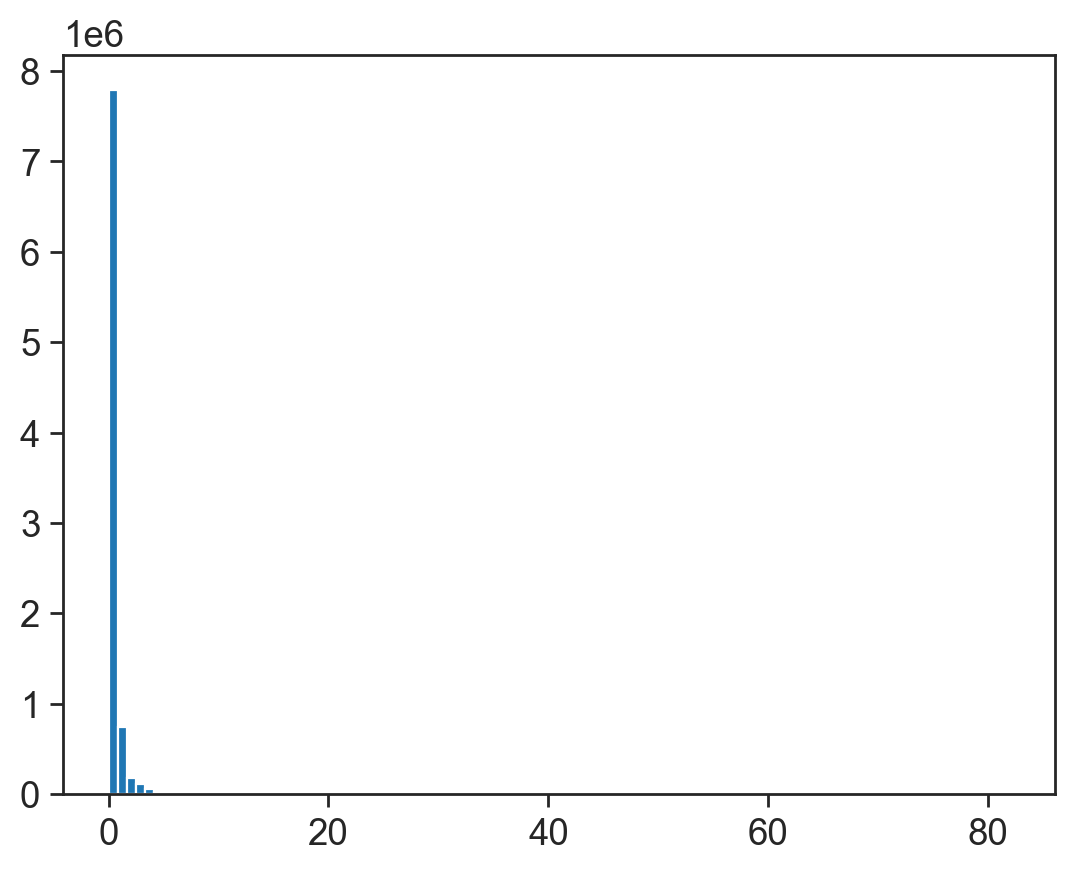

In [21]:
plt.hist(sim_matrix.flatten(), bins=100)

In [22]:
# xn, yn = np.meshgrid(non_military_indices, non_military_indices)
# sim_matrix_nm = sim_matrix[xn, yn]

#### Number of green/brown/neutral occupations per ISCO 1-digit group

In [23]:
isco_lvl1_mapping = {
    1: "Managers",
    2: "Professionals",
    3: "Technicians and associate professionals",
    4: "Clerical support workers",
    5: "Service and sales workers",
    6: "Skilled agricultural, forestry and fishery workers",
    7: "Craft and related trades workers",
    8: "Plant and machine operators and assemblers",
    9: "Elementary occupations",
}

## Iterate over all occupations and compute avg reskilling intensities

In [24]:
# KEY PARAMETER
clsf_version = "classification_slt"

ids_brown = df_metadata.loc[df_metadata[clsf_version] == "brown", :].index.values
ids_green = df_metadata.loc[df_metadata[clsf_version] == "green", :].index.values
ids_neutral = df_metadata.loc[df_metadata[clsf_version] == "neutral", :].index.values

ids_gn = np.concatenate((ids_neutral, ids_green))
ids_gn = np.sort(ids_gn)

#### Case 1: Brown - Green

In [25]:
sim_brown_green = []
for b in tqdm(ids_brown):
    for g in ids_green:
        sim_brown_green.append(sim_matrix[b, g])

np.mean(sim_brown_green)

sim_green_brown = []
for b in tqdm(ids_brown):
    for g in ids_green:
        sim_green_brown.append(sim_matrix[g, b])

np.mean(sim_green_brown)

100%|██████████| 63/63 [00:00<?, ?it/s]


0.4706959706959707

#### Case 2: Brown - Neutral

In [26]:
sim_brown_neutral = []
for b in tqdm(ids_brown):
    for n in ids_neutral:
        sim_brown_neutral.append(sim_matrix[b, n])

np.mean(sim_brown_neutral)

sim_neutral_brown = []
for b in tqdm(ids_brown):
    for n in ids_neutral:
        sim_neutral_brown.append(sim_matrix[n, b])

np.mean(sim_neutral_brown)

100%|██████████| 63/63 [00:00<00:00, 1179.84it/s]


0.4730570543313219

#### Case 3: Neutral - Green

In [27]:
sim_neutral_green = []
for n in tqdm(ids_neutral):
    for g in ids_green:
        sim_neutral_green.append(sim_matrix[n, g])

np.mean(sim_neutral_green)

sim_green_neutral = []
for n in tqdm(ids_neutral):
    for g in ids_green:
        sim_green_neutral.append(sim_matrix[g, n])

np.mean(sim_green_neutral)

100%|██████████| 2833/2833 [00:00<00:00, 41024.66it/s]


0.44669864198632286

#### Case 4: all occupations

In [28]:
ids_all = df_metadata.index.values
sim_all = []
for i in tqdm(ids_all):
    for j in ids_all:
        sim_all.append(sim_matrix[i, j])

100%|██████████| 2987/2987 [00:02<00:00, 1086.59it/s]


#### Case 5: B to G/N

In [29]:
sim_brown_gn = []
for b in tqdm(ids_brown):
    for gn in ids_gn:
        sim_brown_gn.append(sim_matrix[b, gn])

sim_gn_brown = []
for b in tqdm(ids_brown):
    for gn in ids_gn:
        sim_gn_brown.append(sim_matrix[gn, b])

np.mean(sim_brown_gn)
np.mean(sim_gn_brown)

100%|██████████| 63/63 [00:00<00:00, 985.16it/s]


0.47298357327427093

#### Combine in single df

In [30]:
def pad(seq, target_length, padding=None):
    length = len(seq)
    seq.extend([padding] * (target_length - length))
    return seq

In [31]:
if len(sim_green_neutral) > len(sim_brown_neutral):
    padding_reference = sim_green_neutral
else:
    padding_reference = sim_brown_neutral

df = pd.DataFrame(index=range(len(padding_reference)))
df["sim_green_brown"] = pad(sim_green_brown, len(padding_reference), np.nan)
df["sim_brown_green"] = pad(sim_brown_green, len(padding_reference), np.nan)

df["sim_brown_neutral"] = pad(sim_brown_neutral, len(padding_reference), np.nan)
df["sim_neutral_brown"] = pad(sim_neutral_brown, len(padding_reference), np.nan)

df["sim_neutral_green"] = pad(sim_neutral_green, len(padding_reference), np.nan)
df["sim_green_neutral"] = pad(sim_green_neutral, len(padding_reference), np.nan)

In [32]:
df2 = pd.DataFrame(index=range(len(sim_all)))

df2["sim_all"] = pad(sim_all, len(sim_all), np.nan)

df2["sim_green_brown"] = pad(sim_green_brown, len(sim_all), np.nan)
df2["sim_brown_green"] = pad(sim_brown_green, len(sim_all), np.nan)

df2["sim_brown_neutral"] = pad(sim_brown_neutral, len(sim_all), np.nan)
df2["sim_neutral_brown"] = pad(sim_neutral_brown, len(sim_all), np.nan)

df2["sim_neutral_green"] = pad(sim_neutral_green, len(sim_all), np.nan)
df2["sim_green_neutral"] = pad(sim_green_neutral, len(sim_all), np.nan)

In [33]:
df3 = pd.DataFrame(index=range(len(sim_all)))

df3["sim_all"] = pad(sim_all, len(sim_all), np.nan)
df3["sim_brown_gn"] = pad(sim_brown_gn, len(sim_all), np.nan)
df3["sim_gn_brown"] = pad(sim_gn_brown, len(sim_all), np.nan)

#### Save raw data

In [34]:
df3.to_pickle(
    os.path.join(
        useful_paths.data_processed,
        "esco",
        "reskilling_intensity_data_step1_{}.pkl".format(clsf_version),
    )
)
df2.to_pickle(
    os.path.join(
        useful_paths.data_processed,
        "esco",
        "reskilling_intensity_data_step2_{}.pkl".format(clsf_version),
    )
)

#### Visualisations

In [35]:
df.describe()

,sim_green_brown,sim_brown_green,sim_brown_neutral,sim_neutral_brown,sim_neutral_green,sim_green_neutral
count,"5,733.00","5,733.00","178,479.00","178,479.00","257,803.00","257,803.00"
mean,0.47,0.47,0.47,0.47,0.45,0.45
std,2.28,2.28,2.15,2.15,2.18,2.18
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.00,0.00,0.25,0.25,0.00,0.00
max,47.00,47.00,61.75,61.75,67.75,67.75


In [36]:
df2.describe()

,sim_all,sim_green_brown,sim_brown_green,sim_brown_neutral,sim_neutral_brown,sim_neutral_green,sim_green_neutral
count,"8,922,169.00","5,733.00","5,733.00","178,479.00","178,479.00","257,803.00","257,803.00"
mean,0.46,0.47,0.47,0.47,0.47,0.45,0.45
std,2.05,2.28,2.28,2.15,2.15,2.18,2.18
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.25,0.00,0.00,0.25,0.25,0.00,0.00
max,82.00,47.00,47.00,61.75,61.75,67.75,67.75


In [37]:
df3.describe()

,sim_all,sim_brown_gn,sim_gn_brown
count,"8,922,169.00","184,212.00","184,212.00"
mean,0.46,0.47,0.47
std,2.05,2.16,2.16
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,0.00,0.00,0.00
75%,0.25,0.25,0.25
max,82.00,61.75,61.75


In [38]:
import scipy

for col in df2.columns:
    test = scipy.stats.shapiro(df2[col].dropna().values)
    print(col, test)

sim_all ShapiroResult(statistic=0.2084968090057373, pvalue=0.0)
sim_green_brown ShapiroResult(statistic=0.18806308507919312, pvalue=0.0)
sim_brown_green ShapiroResult(statistic=0.18806308507919312, pvalue=0.0)
sim_brown_neutral ShapiroResult(statistic=0.2037813663482666, pvalue=0.0)
sim_neutral_brown ShapiroResult(statistic=0.2037813663482666, pvalue=0.0)
sim_neutral_green ShapiroResult(statistic=0.1844712495803833, pvalue=0.0)
sim_green_neutral ShapiroResult(statistic=0.1844712495803833, pvalue=0.0)


C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\scipy\stats\_morestats.py:1800: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


((array([-5.24607179, -5.08014322, -4.99079556, ...,  4.99079556,
          5.08014322,  5.24607179]),
  array([ 0.,  0.,  0., ..., 79., 82., 82.])),
 (0.9298154320345935, 0.45780566362282593, 0.4536439650285786))

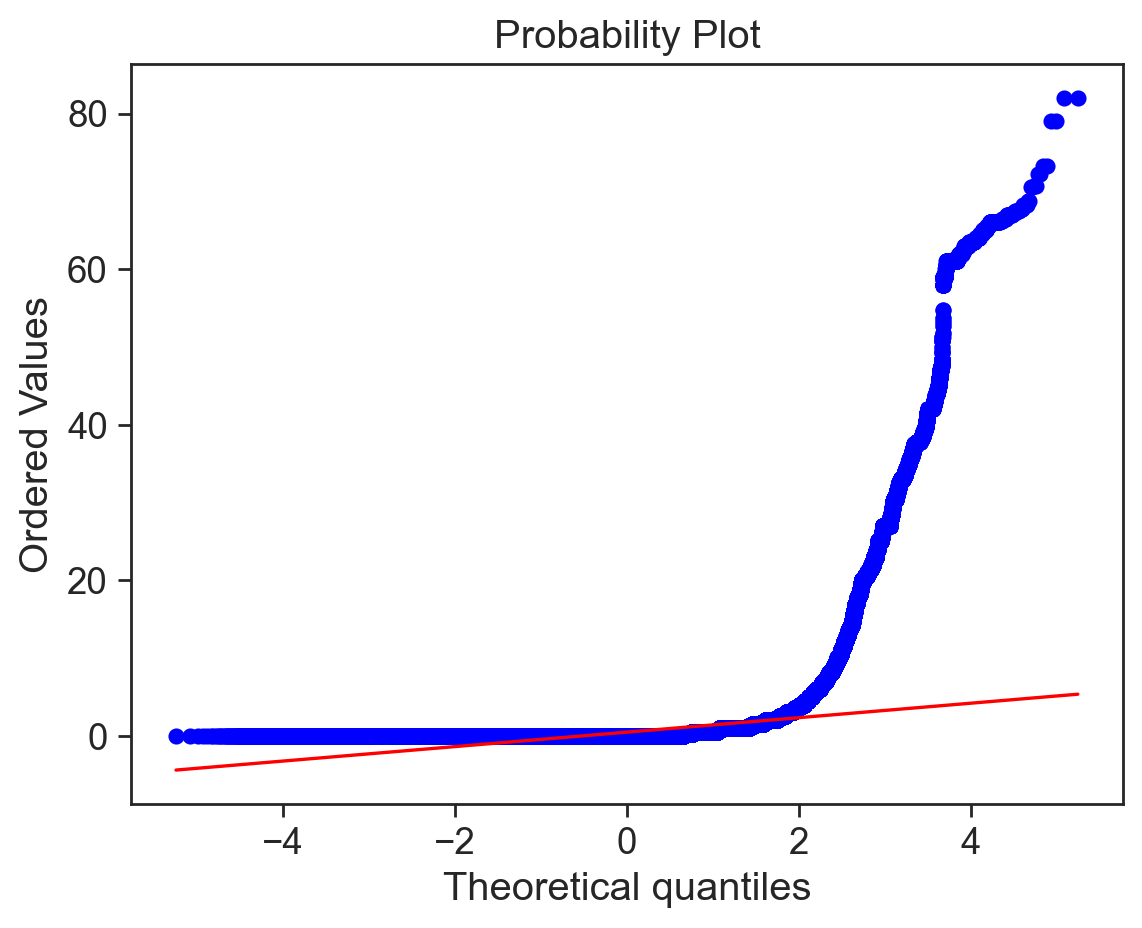

In [39]:
scipy.stats.probplot(df2.sim_all.dropna().values, dist="norm", plot=plt)

## Final plots for paper
- https://stats.stackexchange.com/questions/265323/approaches-for-comparing-visual-representation-of-two-distributions-with-unequal

##### Simple version
- Die verteilung von B->G/N hat viel mehr fläche bei Null skill overlap (unterschied sieht wegen log-y so klein aus!)
- [https://stackoverflow.com/questions/17875341/how-to-make-rug-plot-in-matplotlib](Rugplots)

In [40]:
# read data for SL and SLT
step1_data_sl = pd.read_pickle(
    os.path.join(
        useful_paths.data_processed,
        "esco",
        "reskilling_intensity_data_step1_{}.pkl".format("classification_sl"),
    )
)
step1_data_slt = pd.read_pickle(
    os.path.join(
        useful_paths.data_processed,
        "esco",
        "reskilling_intensity_data_step1_{}.pkl".format("classification_slt"),
    )
)

In [41]:
# combine
step1_data_sl = step1_data_sl.add_suffix("_sl")
step1_data_slt = step1_data_slt.add_suffix("_slt")
step1_data_merged = pd.concat([step1_data_sl, step1_data_slt], axis=1)

In [42]:
# clean
step1_data_merged = step1_data_merged.rename(columns={"sim_all_sl": "sim_all"}).drop(
    columns=["sim_all_slt", "sim_gn_brown_sl", "sim_gn_brown_slt"]
)

In [43]:
step1_data_merged.notna().sum()

sim_all             8922169
sim_brown_gn_sl      575460
sim_brown_gn_slt     184212
dtype: int64

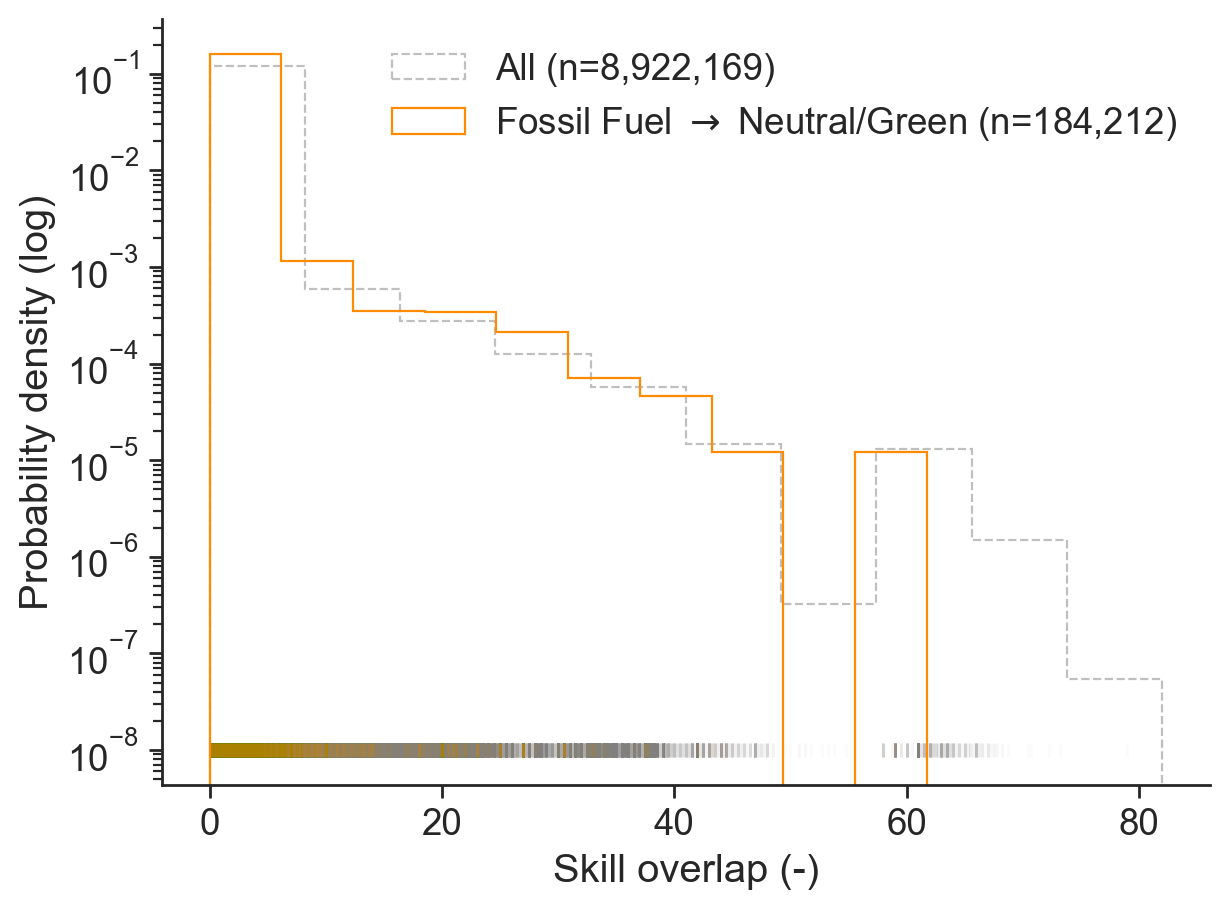

In [52]:
# params
bins = 10
log = "y"
density = True  # density=True normalises the area under each histogram to 1
histtype = "step"
stacked = True
fill = False
alpha_sample = 1
y_loc_rug = 10**-8
alpha_rug = 0.01

# columns, colors and labels
cols = ["sim_all", "sim_brown_gn_slt"]
colors = ["grey", "darkorange"]
labels = [
    "All (n={:,})",
    r"Fossil Fuel $\rightarrow$ Neutral/Green (n={:,})",
]
linestyles = ["--", "-"]
alphas = [0.5, alpha_sample]

# plot
fig, ax = plt.subplots()
for col, color, label, linestyle, alpha in zip(
    cols, colors, labels, linestyles, alphas
):
    x = step1_data_merged[col].dropna()

    # histplots
    plt.hist(
        x,
        bins=bins,
        log=log,
        density=density,
        histtype=histtype,
        stacked=stacked,
        fill=fill,
        alpha=alpha,
        label=label.format(x.shape[0]),
        color=color,
        linestyle=linestyle,
    )

    # rugplots
    ax.plot(x, [y_loc_rug] * len(x), "|", color=color, alpha=alpha_rug)

# style
plt.legend(loc="upper right", fancybox=False, frameon=False)
plt.xlabel("Skill overlap (-)")
plt.ylabel("Probability density (log)")
sns.despine()
plt.tight_layout()

# save
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_intensity",
        "skill_overlap_histogram_simple_main.png",
    ),
    bbox_inches="tight",
    dpi=300,
)

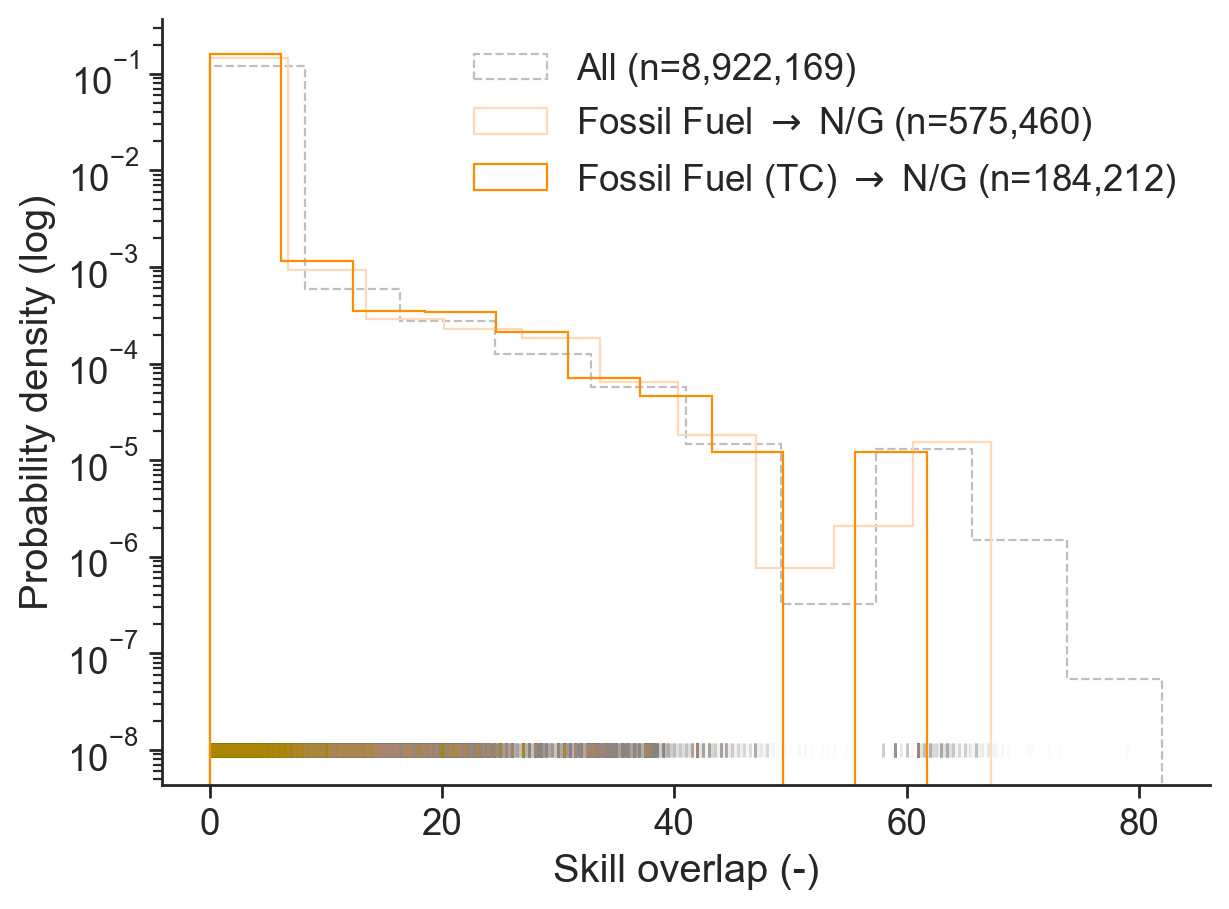

In [53]:
# params
bins = 10
log = "y"
density = True  # density=True normalises the area under each histogram to 1
histtype = "step"
stacked = True
fill = False
alpha_sample = 1
y_loc_rug = 10**-8
alpha_rug = 0.01

# columns, colors and labels
cols = ["sim_all", "sim_brown_gn_sl", "sim_brown_gn_slt"]
colors = ["grey", "peachpuff", "darkorange"]
labels = [
    "All (n={:,})",
    r"Fossil Fuel $\rightarrow$ N/G (n={:,})",
    r"Fossil Fuel (TC) $\rightarrow$ N/G (n={:,})",
]
linestyles = ["--", "-", "-"]
alphas = [0.5, alpha_sample, alpha_sample]

# plot
fig, ax = plt.subplots()
for col, color, label, linestyle, alpha in zip(
    cols, colors, labels, linestyles, alphas
):
    x = step1_data_merged[col].dropna()

    # histplots
    plt.hist(
        x,
        bins=bins,
        log=log,
        density=density,
        histtype=histtype,
        stacked=stacked,
        fill=fill,
        alpha=alpha,
        label=label.format(x.shape[0]),
        color=color,
        linestyle=linestyle,
    )

    # rugplots
    ax.plot(x, [y_loc_rug] * len(x), "|", color=color, alpha=alpha_rug)

# style
plt.legend(loc="upper right", fancybox=False, frameon=False)
plt.xlabel("Skill overlap (-)")
plt.ylabel("Probability density (log)")
sns.despine()
plt.tight_layout()

# save
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_intensity",
        "skill_overlap_histogram_simple_si.png",
    ),
    bbox_inches="tight",
    dpi=300,
)

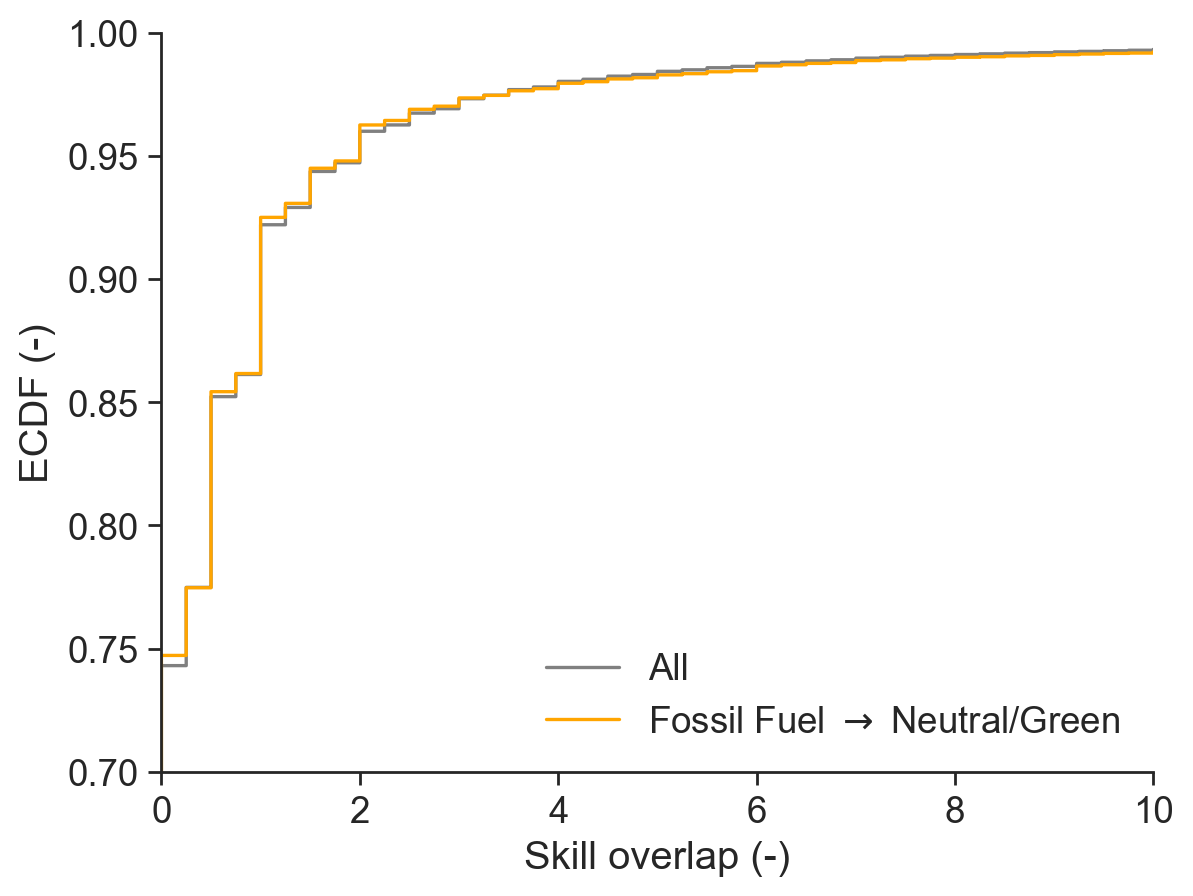

In [54]:
import numpy as np
import statsmodels.api as sm  # recommended import according to the docs
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

cols = ["sim_all", "sim_brown_gn"]
colors = ["grey", "orange"]
labels = ["All", r"Fossil Fuel $\rightarrow$ Neutral/Green"]

for col, color, label in zip(cols, colors, labels):
    x = df3[col].dropna()
    ecdf = sm.distributions.ECDF(x)
    plt.step(ecdf.x, ecdf.y, label=label, color=color, alpha=1)

plt.xlim(0, 10)
plt.ylim(0.7, 1)
plt.xlabel("Skill overlap (-)")
plt.ylabel("ECDF (-)")
plt.legend(loc="lower right", fancybox=False, frameon=False)
sns.despine()

# save
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_intensity",
        "ecdf_simple_{}.png".format(clsf_version),
    ),
    bbox_inches="tight",
    dpi=300,
)

- If F(x1) > G(x2) for all x, the values (meaning the count at the specific skill overlap bin) in x1 tend to be less than those in x2.
- This makes sense!

##### Complex version

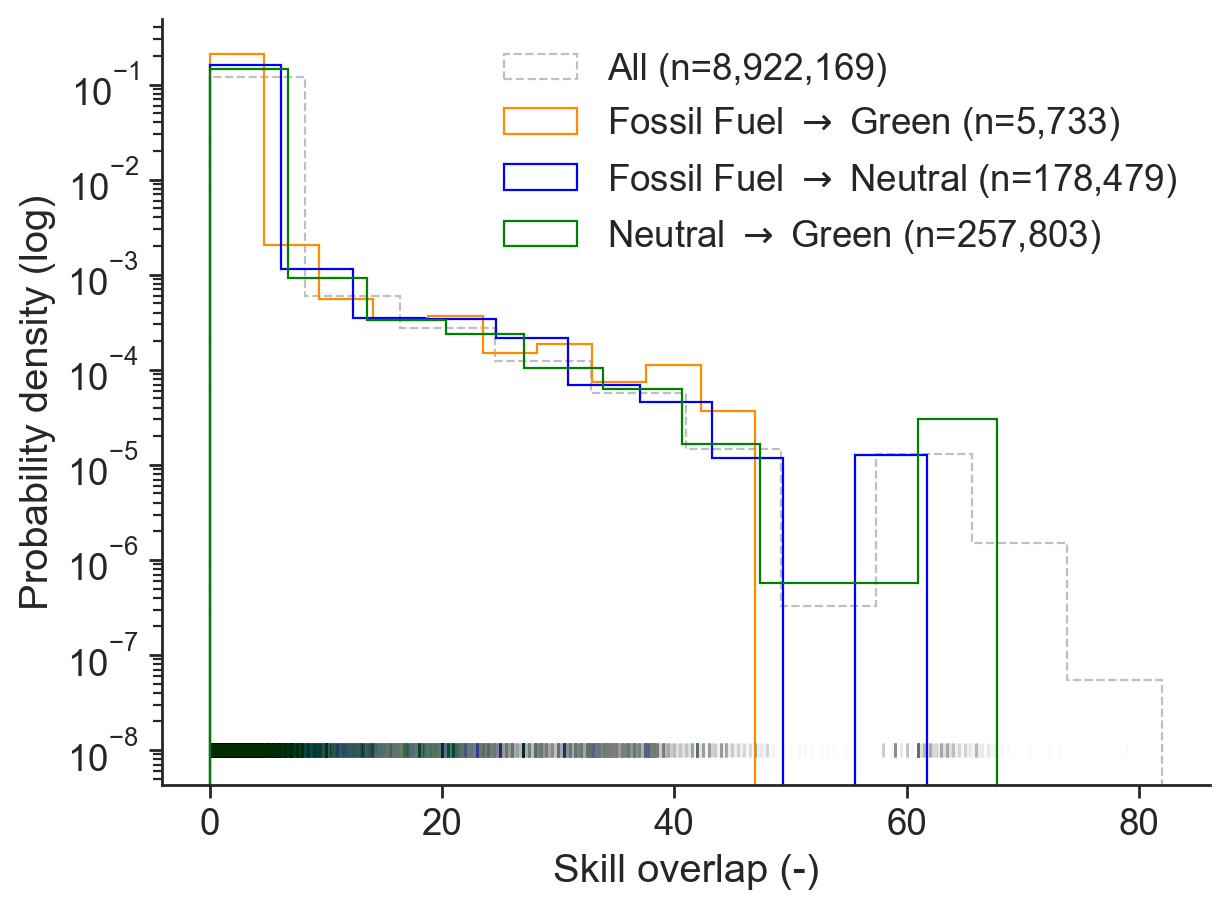

In [55]:
# params
bins = 10
log = "y"
density = True  # density=True normalises the area under each histogram to 1
histtype = "step"
stacked = True
fill = False
alpha_sample = 1
y_loc_rug = 10**-8
alpha_rug = 0.01

# columns, colors and labels
cols = ["sim_all", "sim_brown_green", "sim_brown_neutral", "sim_neutral_green"]
colors = ["grey", "darkorange", "blue", "green"]
labels = [
    "All (n={:,})",
    r"Fossil Fuel $\rightarrow$ Green (n={:,})",
    r"Fossil Fuel $\rightarrow$ Neutral (n={:,})",
    r"Neutral $\rightarrow$ Green (n={:,})",
]
linestyles = ["--", "-", "-", "-"]
alphas = [0.5, alpha_sample, alpha_sample, alpha_sample]

# plot
fig, ax = plt.subplots()
for col, color, label, linestyle, alpha in zip(
    cols, colors, labels, linestyles, alphas
):
    x = df2[col].dropna()

    # histplots
    plt.hist(
        x,
        bins=bins,
        log=log,
        density=density,
        histtype=histtype,
        stacked=stacked,
        fill=fill,
        alpha=alpha,
        label=label.format(x.shape[0]),
        color=color,
        linestyle=linestyle,
    )

    # rugplots
    ax.plot(x, [y_loc_rug] * len(x), '|', color=color, alpha=alpha_rug)

# style
plt.legend(loc="upper right", fancybox=False, frameon=False)
plt.xlabel("Skill overlap (-)")
plt.ylabel("Probability density (log)")
sns.despine()
plt.tight_layout()

# save
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_intensity",
        "skill_overlap_histogram_extended_{}.png".format(clsf_version),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### ECDF
- https://stackoverflow.com/questions/3209362/how-to-plot-empirical-cdf-ecdf

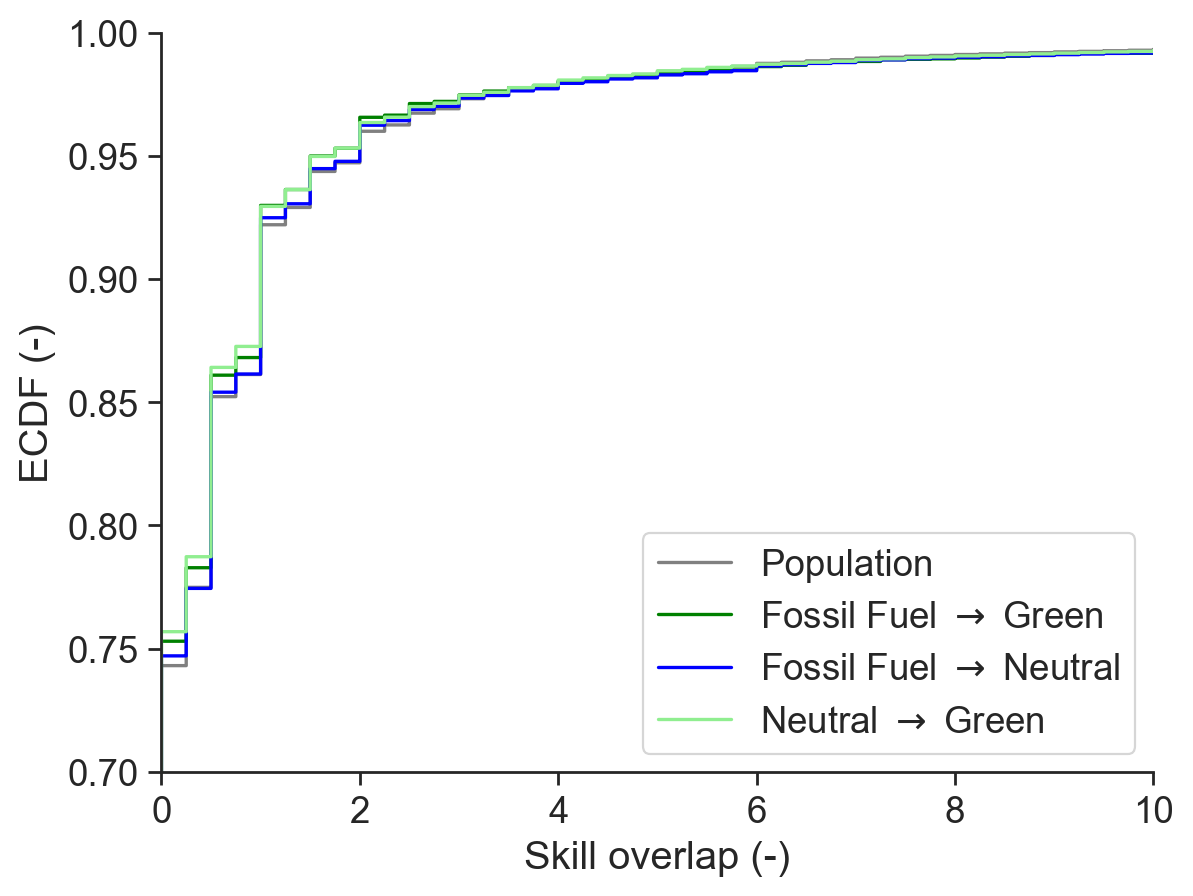

In [56]:
import numpy as np
import statsmodels.api as sm  # recommended import according to the docs
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

cols = ["sim_all", "sim_brown_green", "sim_brown_neutral", "sim_neutral_green"]
colors = ["grey", "green", "blue", "lightgreen"]
labels = ["Population", r"Fossil Fuel $\rightarrow$ Green", r"Fossil Fuel $\rightarrow$ Neutral", r"Neutral $\rightarrow$ Green"]

for col, color, label in zip(cols, colors, labels):
    sample = df2[col].dropna()
    ecdf = sm.distributions.ECDF(sample)
    plt.step(ecdf.x, ecdf.y, label=label, color=color, alpha=1)

plt.xlim(0, 10)
plt.ylim(0.7, 1)
plt.xlabel("Skill overlap (-)")
plt.ylabel("ECDF (-)")
plt.legend(loc="lower right")
sns.despine()

# save
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_intensity",
        "ecdf_extended_{}.png".format(clsf_version),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [49]:
assert 1 == 2

AssertionError: 

## Final stats for paper

##### Kolmogorov-Smirnov Test

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html

Hypothesis testing for ks(x, y):
- two-sided H0: distributions of x, y are identical (if p < thresh, samples come from different distributions)
- less H0: D(x) > D(y), CDF(x) < CDF(y): (if p < thresh, H0 is rejected in favour of H1)

There are three options for the null and corresponding alternative hypothesis that can be selected using the alternative parameter.

    two-sided: The null hypothesis is that the two distributions are identical, F(x)=G(x) for all x; the alternative is that they are not identical.

    less: The null hypothesis is that F(x) >= G(x) for all x; the alternative is that F(x) < G(x) for at least one x.

    greater: The null hypothesis is that F(x) <= G(x) for all x; the alternative is that F(x) > G(x) for at least one x.

Note that the alternative hypotheses describe the CDFs of the underlying distributions, not the observed values. For example, suppose x1 ~ F and x2 ~ G. If F(x) > G(x) for all x, the values in x1 tend to be less than those in x2.

**If F(x1) > G(x2) for all x, the values in x1 tend to be less than those in x2.**

##### Test results

**Reasoning**:
- If the p-value is higher than our threshold, the data are distributed according to the overall skill overlap distribution.
- If the p-value is lower than our threshold (e.g. p=0.001), we reject the null hypothesis in favor of the default “two-sided” alternative: the data are not distributed according to the overall skill overlap distribution.

**Results for SL**:
1) Distributions of POP and SAMPLE(B->G/N) are statistically distinguishable: but which one is higher? | '0.0057, 6.14e-16'
    - Values in POP tend to be greater than values in SAMPLE(B->G/N): *brown to green or neutral harder than on average* | '0.0057, 3.07e-16'
2) Distributions of POP and SAMPLE(B->G) are statistically indistinguishable: *brown to green as doable as the average* | '0.0087, 1.15E-1'
3) Distributions of POP and SAMPLE(B->N) are statistically distinguishable: but which one is higher? | '0.0062, 8.21e-18'
    - Values in POP tend to be greater than values in SAMPLE(B->N): *brown to neutral harder than on average* | '0.0062, 4.10e-18'
4) Distributions of POP and SAMPLE(N->G) are statistically distinguishable: but which one is higher? | '0.014, 2.35e-41'
    - Values in POP tend to be smaller than values in SAMPLE(N->G): *neutral to green easier than on average* | '0.014, 1.18e-41'

**Results for SLT**:
1) Distributions of POP and SAMPLE(B->G/N) are statistically indistinguishable: *brown to green or neutral as doable as the average* | '0.0041, 4.21e-3'
2) Distributions of POP and SAMPLE(B->G) are statistically indistinguishable (even to a much smaller extent than for SL): *brown to green as doable as the average* | '0.0097, 6.46e-1'
3) Distributions of POP and SAMPLE(B->N) are statistically indistinguishable: *brown to neutral as doable as the average* | '0.004, 8.46e-3'
4) Distributions of POP and SAMPLE(N->G) are statistically distinguishable: but which one is higher? | '0.014, 1.06e-41'
    - Values in POP tend to be smaller than values in SAMPLE(N->G), *neutral to green easier than on average* | '0.014, 5.33e-42'

In [ ]:
from scipy import stats
from decimal import Decimal
import scikit_posthocs as sp

##### H0: SAMPLE(B->G/N) < POP

In [ ]:
# variables
x = "sim_brown_gn"
y = "sim_all"
df = df3[["sim_all", "sim_brown_gn"]]

# classification version and comparison variables
print("-----------------------------------------------------------------------")
print(clsf_version, ": x1={} vs. x2={}".format(x, y))
print("-----------------------------------------------------------------------")


# 1. Kruskall Wallis H-Test: H0 ... samples have the same population median
h, pval = stats.kruskal(df[x].dropna(), df[y].dropna())
print("H-Test: H = {:.3}, p = {:.2e}".format(h, Decimal(pval)))

# 2. KS Test (two-sided)
d, pval = stats.kstest(df[x].dropna(), df[y].dropna(), alternative="two-sided")
print("KS-Test (two-sided): D = {:.2}, p = {:.2e}".format(d, Decimal(pval)))

# post-hoc test
dfm = df.melt(var_name="groups", value_name="values").dropna(subset=["values"])
pvals_posthoc = sp.posthoc_dunn(
    dfm, val_col="values", group_col="groups", p_adjust="bonferroni"
)

# 3. KS Test (one-sided)
# greater: H0 = F(x1) <= G(x2) meaning x1 > x2 | IF p > 0.001, we cannot reject H0
d, pval = stats.kstest(df[x].dropna(), df[y].dropna(), alternative="greater")
print("KS-Test (one-sided, greater): D = {:.2}, p = {:.2e}".format(d, Decimal(pval)))

# less: H0 = F(x1) >= G(x2) meaning x1 < x2 | IF p > 0.001, we cannot reject H0
d, pval = stats.kstest(df[x].dropna(), df[y].dropna(), alternative="less")
print("KS-Test (one-sided, less): D = {:.2}, p = {:.2e}".format(d, Decimal(pval)))
print("-----------------------------------------------------------------------")
print(pvals_posthoc)

"greater: The null hypothesis is that F(x) <= G(x) for all x; the alternative is that F(x) > G(x) for at least one x."

##### H0: SAMPLE(B->N) < POP

In [ ]:
# variables
x = "sim_brown_neutral"
y = "sim_all"
df = df2[["sim_all", "sim_brown_neutral", "sim_brown_green", "sim_neutral_green"]]

# classification version and comparison variables
print("-----------------------------------------------------------------------")
print(clsf_version, ": x1={} vs. x2={}".format(x, y))
print("-----------------------------------------------------------------------")


# 1. Kruskall Wallis H-Test: H0 ... samples have the same population median
h, pval = stats.kruskal(df[x].dropna(), df[y].dropna())
print("H-Test: H = {:.3}, p = {:.2e}".format(h, Decimal(pval)))

# 2. KS Test (two-sided)
d, pval = stats.kstest(df[x].dropna(), df[y].dropna(), alternative="two-sided")
print("KS-Test (two-sided): D = {:.2}, p = {:.2e}".format(d, Decimal(pval)))

# post-hoc test
dfm = df.melt(var_name="groups", value_name="values").dropna(subset=["values"])
pvals_posthoc = sp.posthoc_dunn(
    dfm, val_col="values", group_col="groups", p_adjust="bonferroni"
)

# 3. KS Test (one-sided)
# greater: H0 = F(x1) <= G(x2) meaning x1 > x2 | IF p > 0.001, we cannot reject H0
d, pval = stats.kstest(df[x].dropna(), df[y].dropna(), alternative="greater")
print("KS-Test (one-sided, greater): D = {:.2}, p = {:.2e}".format(d, Decimal(pval)))

# less: H0 = F(x1) >= G(x2) meaning x1 < x2 | IF p > 0.001, we cannot reject H0
d, pval = stats.kstest(df[x].dropna(), df[y].dropna(), alternative="less")
print("KS-Test (one-sided, less): D = {:.2}, p = {:.2e}".format(d, Decimal(pval)))
print("-----------------------------------------------------------------------")
print(pvals_posthoc)

##### H0: SAMPLE(B->G) > POP

In [ ]:
# variables
x = "sim_brown_green"
y = "sim_all"
df = df2[["sim_all", "sim_brown_neutral", "sim_brown_green", "sim_neutral_green"]]

# classification version and comparison variables
print("-----------------------------------------------------------------------")
print(clsf_version, ": x1={} vs. x2={}".format(x, y))
print("-----------------------------------------------------------------------")


# 1. Kruskall Wallis H-Test: H0 ... samples have the same population median
h, pval = stats.kruskal(df[x].dropna(), df[y].dropna())
print("H-Test: H = {:.3}, p = {:.2e}".format(h, Decimal(pval)))

# 2. KS Test (two-sided)
d, pval = stats.kstest(df[x].dropna(), df[y].dropna(), alternative="two-sided")
print("KS-Test (two-sided): D = {:.2}, p = {:.2e}".format(d, Decimal(pval)))

# post-hoc test
dfm = df.melt(var_name="groups", value_name="values").dropna(subset=["values"])
pvals_posthoc = sp.posthoc_dunn(
    dfm, val_col="values", group_col="groups", p_adjust="bonferroni"
)

# 3. KS Test (one-sided)
# greater: H0 = F(x1) <= G(x2) meaning x1 > x2 | IF p > 0.001, we cannot reject H0
d, pval = stats.kstest(df[x].dropna(), df[y].dropna(), alternative="greater")
print("KS-Test (one-sided, greater): D = {:.2}, p = {:.2e}".format(d, Decimal(pval)))

# less: H0 = F(x1) >= G(x2) meaning x1 < x2 | IF p > 0.001, we cannot reject H0
d, pval = stats.kstest(df[x].dropna(), df[y].dropna(), alternative="less")
print("KS-Test (one-sided, less): D = {:.2}, p = {:.2e}".format(d, Decimal(pval)))
print("-----------------------------------------------------------------------")
print(pvals_posthoc)

##### H0: SAMPLE(N->G) > POP

In [ ]:
# variables
x = "sim_neutral_green"
y = "sim_all"
df = df2[["sim_all", "sim_brown_neutral", "sim_brown_green", "sim_neutral_green"]]

# classification version and comparison variables
print("-----------------------------------------------------------------------")
print(clsf_version, ": x1={} vs. x2={}".format(x, y))
print("-----------------------------------------------------------------------")


# 1. Kruskall Wallis H-Test: H0 ... samples have the same population median
h, pval = stats.kruskal(df[x].dropna(), df[y].dropna())
print("H-Test: H = {:.3}, p = {:.2e}".format(h, Decimal(pval)))

# 2. KS Test (two-sided)
d, pval = stats.kstest(df[x].dropna(), df[y].dropna(), alternative="two-sided")
print("KS-Test (two-sided): D = {:.2}, p = {:.2e}".format(d, Decimal(pval)))

# post-hoc test
dfm = df.melt(var_name="groups", value_name="values").dropna(subset=["values"])
pvals_posthoc = sp.posthoc_dunn(
    dfm, val_col="values", group_col="groups", p_adjust="bonferroni"
)

# 3. KS Test (one-sided)
# greater: H0 = F(x1) <= G(x2) meaning x1 > x2 | IF p > 0.001, we cannot reject H0
d, pval = stats.kstest(df[x].dropna(), df[y].dropna(), alternative="greater")
print("KS-Test (one-sided, greater): D = {:.2}, p = {:.2e}".format(d, Decimal(pval)))

# less: H0 = F(x1) >= G(x2) meaning x1 < x2 | IF p > 0.001, we cannot reject H0
d, pval = stats.kstest(df[x].dropna(), df[y].dropna(), alternative="less")
print("KS-Test (one-sided, less): D = {:.2}, p = {:.2e}".format(d, Decimal(pval)))
print("-----------------------------------------------------------------------")
print(pvals_posthoc)

In [ ]:
pvals_posthoc.loc["sim_neutral_green", "sim_all"]

In [ ]:
assert 1 == 2

In [ ]:
# less: H0 = F(x1) >= G(x2) meaning x1 < x2 | IF p > 0.001, we cannot reject H0
# greater: H0 = F(x1) <= G(x2) meaning x1 < x2 | IF p > 0.001, we cannot reject H0

# left=assumed to have a higher mean, right=assumed to have a lower mean | we expect H0 to be rejected with alternative="less" |
d, pval = stats.ks_2samp(
    df3.sim_all.dropna(), df3.sim_brown_gn.dropna(), alternative="greater"
)
"{:.2}, {:.2e}".format(d, Decimal(pval))

Distributions of POP and SAMPLE(B->G) are statistically indistinguishable: brown to green transitions are as doable as the average | (0.01, 0.11)

In [ ]:
# less: values_left < values_right
# greater: values_left > values_right
d, pval = stats.kstest(
    df2.sim_brown_green.dropna(), df2.sim_all.dropna(), alternative="two-sided"
)
"{:.2}, {:.2e}".format(d, Decimal(pval))

Distributions of POP and SAMPLE(B->N) are statistically distinguishable (only at p<0.01 for SLT): but which one is higher? | (0.01, 0.00)

In [ ]:
d, pval = stats.kstest(
    df2.sim_brown_neutral.dropna(), df2.sim_all.dropna(), alternative="two-sided"
)
"{:.2}, {:.2e}".format(d, Decimal(pval))

--> Values in POP tend to be greater than values in SAMPLE(B->N) | (0.01, 0.00)

In [ ]:
# less: values_left < values_right
# greater: values_left > values_right
d, pval = stats.kstest(
    df2.sim_brown_neutral.dropna(), df2.sim_all.dropna(), alternative="greater"
)
"{:.2}, {:.2e}".format(d, Decimal(pval))

Distributions of POP and SAMPLE(N->G) are statistically distinguishable: but which one is higher? | (0.01, 0.00)

In [ ]:
d, pval = stats.kstest(
    df2.sim_neutral_green.dropna(), df2.sim_all.dropna(), alternative="two-sided"
)
"{:.2}, {:.2e}".format(d, Decimal(pval))

--> Values in POP tend to be smaller than values in SAMPLE(N->G) | (0.01, 0.00)

In [ ]:
# less: values_left < values_right
# greater: values_left > values_right
d, pval = stats.kstest(
    df2.sim_neutral_green.dropna(), df2.sim_all.dropna(), alternative="greater"
)
"{:.2}, {:.2e}".format(d, Decimal(pval))

Brown->Green vs Brown->Neutral

In [ ]:
# less: values_left < values_right
# greater: values_left > values_right
d, pval = stats.kstest(
    df2.sim_brown_green.dropna(), df2.sim_brown_neutral.dropna(), alternative="greater"
)
"{:.2}, {:.2e}".format(d, Decimal(pval))

In [ ]:
assert 1 == 2

#### Step 1: How difficult to move out of brown?

In [ ]:
aggregators = ["mean", "median"]

col_sel = ["sim_brown_gn"]
col_rename = {
    "sim_brown_gn": "Brown to Green/Neutral",
}

# ["#807dba", "#4a1486", "#f16913", "#8c2d04", "#4292c6", "#084594"]
vline_colors = ["#4292c6"]
alpha = 0.7
y_text = 9000

for aggregator in aggregators:
    with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=1.5):
        ax = sns.histplot(
            data=df3[col_sel].rename(columns=col_rename),
            stat="count",
            palette=vline_colors,
            alpha=alpha,
            legend=None,
        )

        # indicate central tendencies
        ax.axvline(
            df3.sim_brown_gn.aggregate(aggregator),
            color="#4292c6",
            linestyle="-",
            label="$\mu_{b-gn}$",
        )
        plt.text(
            df3.sim_brown_gn.aggregate(aggregator),
            y_text,
            "$\mu_{b-gn}$",
            rotation=90,
            va="bottom",
            ha="center",
        )

        ax.axvline(
            df3.sim_all.aggregate(aggregator),
            color="black",
            linestyle="--",
            label="$\mu$",
        )
        plt.text(
            df3.sim_all.aggregate(aggregator),
            y_text,
            "$\mu$",
            rotation=90,
            va="bottom",
            ha="center",
        )

        # labelling
        ax.set_xlim(-0.01, 0.5)
        # plt.yscale("log")
        ax.set_xlabel("Occupation similarity [-]")
        sns.despine()
        plt.tight_layout()

        plt.savefig(
            os.path.join(
                useful_paths.figure_dir,
                "reskilling_intensity",
                "occ_sim_by_gbn_kanders_matrix_{}_step1.png".format(aggregator),
            ),
            bbox_inches="tight",
            dpi=300,
        )
        # plt.clf()

#### Step 2: Easier to move into green or neutral?

In [ ]:
aggregators = ["mean", "median"]

col_sel = ["sim_brown_green", "sim_brown_neutral"]
col_rename = {
    "sim_brown_green": "Brown to Green",
    "sim_brown_neutral": "Brown to Neutral",
}
vline_colors = ["green", "#4292c6"]
alpha = 0.7
y_text = 8200

for aggregator in aggregators:
    with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=1.5):
        ax = sns.histplot(
            data=df[col_sel].rename(columns=col_rename),
            stat="count",
            palette=vline_colors,
            alpha=alpha,
        )

        for val, color in zip(df[col_sel].aggregate(aggregator).values, vline_colors):
            ax.axvline(val, color=color)

        # indicate overall median
        ax.axvline(
            df2.sim_all.aggregate(aggregator),
            color="black",
            linestyle="--",
            label="sim_all",
        )
        plt.text(
            df2.sim_all.aggregate(aggregator),
            y_text,
            "$\mu$",
            rotation=90,
            va="bottom",
            ha="right",
            fontsize=8,
        )
        plt.text(
            df2.sim_brown_green.aggregate(aggregator),
            y_text,
            "$\mu_{b-g}$",
            rotation=90,
            va="bottom",
            ha="left",
            fontsize=8,
        )
        plt.text(
            df2.sim_brown_neutral.aggregate(aggregator),
            y_text,
            "$\mu_{b-n}$",
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=8,
        )

        ax.set_xlim(-0.01, 0.5)
        ax.set_xlabel("Occupation similarity [-]")

        sns.despine()
        plt.tight_layout()

        plt.savefig(
            os.path.join(
                useful_paths.figure_dir,
                "reskilling_intensity",
                "occ_sim_by_gbn_kanders_matrix_{}_step2.png".format(aggregator),
            ),
            bbox_inches="tight",
            dpi=300,
        )
        # plt.clf()

#### Difference of central tendencies and post-hoc tests

Extensive comparison

In [ ]:
# Tukey-HSD
import statsmodels.stats.multicomp as mc

df = df2
comp = mc.MultiComparison(df.melt().dropna().value, df.melt().dropna().variable)
post_hoc_res = comp.tukeyhsd(alpha=0.001)
post_hoc_res.summary()

Smaller comparison

In [ ]:
df = df3
comp = mc.MultiComparison(df.melt().dropna().value, df.melt().dropna().variable)
post_hoc_res = comp.tukeyhsd(alpha=0.001)
post_hoc_res.summary()

In [ ]:
# Kruskall-Wallis H-test

# Appendix
scipy.stats.kruskal(
    df.sim_brown_green.dropna().values,
    df.sim_green_brown.dropna().values,
    df.sim_brown_neutral.dropna().values,
    df.sim_neutral_brown.dropna().values,
    df.sim_green_neutral.dropna().values,
    df.sim_neutral_green.dropna().values,
)

# Main
scipy.stats.kruskal(
    df.sim_brown_green.dropna().values,
    df.sim_brown_neutral.dropna().values,
    df.sim_neutral_green.dropna().values,
)

In [ ]:
import scikit_posthocs as sp

dfm = df.melt(var_name="groups", value_name="values").dropna(subset=["values"])

sp.posthoc_dunn(dfm, val_col="values", group_col="groups", p_adjust="bonferroni")

In [ ]:
# Appendix
df2m = df2.melt(var_name="groups", value_name="values").dropna(subset=["values"])

sp.posthoc_dunn(df2m, val_col="values", group_col="groups", p_adjust="bonferroni")

In [ ]:
delete = ["sim_green_brown", "sim_neutral_brown", "sim_green_neutral"]

df3m = (
    df2.drop(columns=delete)
    .melt(var_name="groups", value_name="values")
    .dropna(subset=["values"])
)

# Main
sp.posthoc_dunn(df3m, val_col="values", group_col="groups", p_adjust="bonferroni")

#### Repeat analysis at the level of ISCO-08 1-digit groups (within-groups)
- brown-green vs. brown-neutral (no reverse directions)
- look at within-group similarities

In [ ]:
results = {}
for grp, df_isco1 in df_metadata.groupby("isco_level_1"):
    # print(grp, df.shape)

    # get ids of groups in sub-df
    ids_brown = df_isco1.loc[df_isco1.is_brown == True, :].index.values
    ids_green = df_isco1.loc[df_isco1.is_green == True, :].index.values
    ids_neutral = df_isco1.loc[df_isco1.is_neutral == True, :].index.values
    ids_all = df_isco1.index.values

    # brown - green
    sim_brown_green = []
    for b in ids_brown:
        for g in ids_green:
            sim_brown_green.append(sim_matrix[b, g])

    sim_brown_neutral = []
    for b in ids_brown:
        for n in ids_neutral:
            sim_brown_neutral.append(sim_matrix[b, n])

    # all
    sim_all = []
    for i in ids_all:
        for j in ids_all:
            sim_all.append(sim_matrix[i, j])

    # Kruskall-Wallis H-test
    H, p_bg_bn = scipy.stats.kruskal(sim_brown_green, sim_brown_neutral)
    H_bg, p_bg_all = scipy.stats.kruskal(sim_brown_green, sim_all)
    H_bn, p_bn_all = scipy.stats.kruskal(sim_brown_neutral, sim_all)

    # store results
    results[grp] = [
        np.nanmedian(sim_brown_green),
        np.nanmedian(sim_brown_neutral),
        np.nanmedian(sim_all),
        p_bg_bn,
        p_bg_all,
        p_bn_all,
    ]

In [ ]:
results

In [ ]:
df_results = pd.DataFrame.from_dict(
    results,
    orient="index",
    columns=[
        "$M_{bg}$",
        "$M_{bn}$",
        "$M_{all}$",
        "$p_{bg-bn}$",
        "$p_{bg-all}$",
        "$p_{bn-all}$",
    ],
)

df_results = df_results.reset_index().rename(columns={"index": "ISCO"})
df_results["Major group"] = [isco_lvl1_mapping[val] for val in df_results.ISCO.values]

col_order = [
    "ISCO",
    "Major group",
    "$M_{bg}$",
    "$M_{bn}$",
    "$M_{all}$",
    "$p_{bg-bn}$",
    "$p_{bg-all}$",
    "$p_{bn-all}$",
]

df_results = df_results[col_order]

# store
# df_results.to_csv(
#     os.path.join(data_processed, "gbn_median_sims_by_isco_lvl1_v2.csv"),
#     float_format='%.3f',
#     index=False
# )

df_results

#### Repeat analysis at the level of ISCO-08 1-digit groups (cross-group)
- brown-green vs. brown-neutral (no reverse directions)
- look at cross-group similarities (heatmaps)

In [ ]:
df_metadata.loc[df_metadata.isco_level_1 != 1]
df_metadata.query("isco_level_1 != 1")

In [ ]:
results_cross_group = []

# loop over source group
for grp_source, df_source in df_metadata.groupby("isco_level_1"):
    # df_metadata_sub = df_metadata.loc[df_metadata.isco_level_1 != grp]

    # get ids of groups in source sub-df
    ids_brown_source = df_source.loc[df_source.is_brown == True, :].index.values
    ids_green_source = df_source.loc[df_source.is_green == True, :].index.values
    ids_neutral_source = df_source.loc[df_source.is_neutral == True, :].index.values

    for grp_target, df_target in df_metadata.groupby("isco_level_1"):

        # get ids of groups in target sub-df
        ids_brown_target = df_target.loc[df_target.is_brown == True, :].index.values
        ids_green_target = df_target.loc[df_target.is_green == True, :].index.values
        ids_neutral_target = df_target.loc[df_target.is_neutral == True, :].index.values

        # brown - green
        sim_brown_green = []
        for b in ids_brown_source:
            for g in ids_green_target:
                sim_brown_green.append(sim_matrix[b, g])

        # brown - neutral
        sim_brown_neutral = []
        for b in ids_brown_source:
            for n in ids_neutral_target:
                sim_brown_neutral.append(sim_matrix[b, n])

        # store
        results_cross_group.append(
            [
                grp_source,
                grp_target,
                np.nanmedian(sim_brown_green),
                np.nanmedian(sim_brown_neutral),
            ]
        )

In [ ]:
mat_results_bg = np.zeros((9, 9))
mat_results_bn = np.zeros((9, 9))

for l in results_cross_group:
    x = l[0]
    y = l[1]
    bg = l[2]
    bn = l[3]

    mat_results_bg[x - 1, y - 1] = bg
    mat_results_bn[x - 1, y - 1] = bn

In [ ]:
high = "#08306b"
medium = "#2171b5"
low = "#6baed6"
isco_lvl1_skill_level_colors = {
    0: high,
    1: high,
    2: high,
    3: medium,
    4: medium,
    5: medium,
    6: medium,
    7: medium,
    8: low,
}

In [ ]:
with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=1.5):
    fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True)

    # Brown - Green
    df_results_bg = pd.DataFrame(
        mat_results_bg,
        index=list(isco_lvl1_mapping.values()),
        columns=list(isco_lvl1_mapping.values()),
    )

    sns.heatmap(
        data=df_results_bg,
        cmap=plt.get_cmap("Blues", 14),
        vmin=0,
        vmax=0.35,
        annot=True,
        square=True,
        cbar=False,
        ax=ax1,
        fmt=".2f",
    )

    ax1.set_title("Brown-Green")
    # plt.tight_layout()

    # plt.savefig(
    #    os.path.join(figure_dir, "RQ3", "avg_sims_heatmap_bg.png"),
    #    bbox_inches="tight",
    #    dpi=150
    # )

    # Brown - Neutral
    df_results_bn = pd.DataFrame(
        mat_results_bn,
        index=list(isco_lvl1_mapping.values()),
        columns=list(isco_lvl1_mapping.values()),
    )

    sns.heatmap(
        data=df_results_bn,
        cmap=plt.get_cmap("Blues", 14),
        vmin=0,
        vmax=0.35,
        annot=True,
        square=True,
        cbar=False,
        ax=ax2,
        fmt=".2f",
    )

    ax2.set_title("Brown-Neutral")

    # color tick labels
    for k, v in isco_lvl1_skill_level_colors.items():
        ax1.get_xticklabels()[k].set_color(v)
        ax1.get_yticklabels()[k].set_color(v)
        ax2.get_xticklabels()[k].set_color(v)

    plt.tight_layout()

    # plt.savefig(
    #     os.path.join(figure_dir, "RQ3", "avg_sims_heatmap_combined.png"),
    #     bbox_inches="tight",
    #     dpi=300
    # )

In [ ]:
df_results_delta = df_results_bg - df_results_bn

with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=1.5):
    ax = sns.heatmap(
        data=df_results_delta,
        cmap=plt.get_cmap("PiYG"),
        center=0,
        annot=True,
        square=True,
        cbar=False,
        fmt=".2f",
    )

    # color tick labels
    for k, v in isco_lvl1_skill_level_colors.items():
        ax.get_xticklabels()[k].set_color(v)
        ax.get_yticklabels()[k].set_color(v)

    ax.set_title("Brown-Green minus Brown-Neutral")
    plt.tight_layout()

    # plt.savefig(
    #     os.path.join(figure_dir, "RQ3", "avg_sims_heatmap_bg_minus_bn.png"),
    #     bbox_inches="tight",
    #     dpi=300
    # )